# CSD Early Warning Classifier: Boundary Prediction with Cross-Task/Cross-Model Evaluation

**Summary:** This notebook builds binary classifiers predicting whether a model-task pair is within 2 difficulty levels of its capability boundary (d\*) using 6 CSD (Critical Slowing Down) indicator features plus delta/trend extensions. The classifiers are evaluated via Leave-One-Pair-Out (LOPO), Leave-One-Task-Out (LOTO), and Leave-One-Model-Out (LOMO) cross-validation across 5 model-task pairs.

**Key result:** CSD-LogReg-full achieves LOPO macro-F1=0.814 and AUROC=0.897, a 16.4% F1 improvement over the best single-feature baseline (variance_only F1=0.699).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
# Colab uses Python 3.12; locally we install best-available compatible versions
if 'google.colab' not in sys.modules:
    vi = sys.version_info
    if vi >= (3, 11):
        _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')
    else:
        _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aii-pipeline 0.1.0 requires pandas>=2.3.0, but you have pandas 2.2.2 which is incompatible.
aii-pipeline 0.1.0 requires scikit-learn>=1.7.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger
from scipy.stats import kendalltau
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

# Configure logging for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load Data

Load the mini demo dataset from GitHub (with local fallback). The data contains CSD indicator features for 5 model-task pairs across multiple difficulty levels.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/experiment_iter3_csd_early_warni/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
df = pd.DataFrame(data["rows"])
df["pair_id"] = df["task"] + "__" + df["model"]
print(f"Loaded {len(df)} rows, {df.pair_id.nunique()} unique pairs")
print(f"Unique pairs: {sorted(df.pair_id.unique().tolist())}")
df.head()

Loaded 91 rows, 5 unique pairs
Unique pairs: ['arithmetic__google/gemini-2.0-flash-001', 'arithmetic__meta-llama/llama-3.1-8b-instruct', 'graph_coloring__google/gemini-2.0-flash-001', 'graph_coloring__google/gemini-2.0-flash-lite-001', 'graph_coloring__openai/gpt-4o-mini']


,task,model,difficulty,d_star,accuracy,embedding_variance,dip_statistic,silhouette_k2,bimodality_coefficient,disagreement_rate,ashman_d,pair_id
0,arithmetic,google/gemini-2.0-flash-001,2,15,0.50,0.305137,0.155132,0.4149,0.7056,0.86,0.0,arithmetic__google/gemini-2.0-flash-001
1,arithmetic,google/gemini-2.0-flash-001,4,15,0.62,0.226287,0.130964,0.3252,0.6426,0.84,0.0,arithmetic__google/gemini-2.0-flash-001
2,arithmetic,google/gemini-2.0-flash-001,6,15,0.56,0.248603,0.087524,0.3574,0.5000,0.86,0.0,arithmetic__google/gemini-2.0-flash-001
3,arithmetic,google/gemini-2.0-flash-001,8,15,0.66,0.244000,0.105840,0.2703,0.5117,0.84,0.0,arithmetic__google/gemini-2.0-flash-001
4,arithmetic,google/gemini-2.0-flash-001,10,15,0.54,0.175533,0.089268,0.2697,0.6971,0.84,0.0,arithmetic__google/gemini-2.0-flash-001


## Configuration

All tunable parameters are defined here. Start with minimum values for fast testing.

In [5]:
# Core CSD features (the zero-cost indicators)
CSD_FEATURES = [
    "embedding_variance", "dip_statistic", "silhouette_k2",
    "bimodality_coefficient", "disagreement_rate", "ashman_d",
]

# Threshold search resolution (original: 100)
THRESHOLD_GRID_SIZE = 100

# Probability threshold search resolution (original: 81 points from 0.1 to 0.9)
PROB_THRESHOLD_POINTS = 81

# Regularization strengths to try (original: [0.01, 0.1, 0.5, 1.0, 5.0, 10.0])
C_VALUES = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

# Random Forest n_estimators (original: 50 for CV, 100 for importance)
RF_N_ESTIMATORS_CV = 50
RF_N_ESTIMATORS_IMPORTANCE = 100

# Trend window size (original: 5 levels trailing)
TREND_WINDOW = 5

# Number of CPUs for parallel jobs
NUM_CPUS = min(os.cpu_count() or 1, 4)

## Helper Functions

Threshold optimization, metric computation, and feature threshold application.

In [6]:
def optimize_threshold(feature_series: pd.Series, labels: np.ndarray) -> tuple:
    """Find threshold maximizing F1 on training data. Returns (best_f1, best_thresh, direction)."""
    best_f1, best_t, best_dir = 0.0, float(feature_series.median()), ">="
    vals = feature_series.values
    for t in np.linspace(vals.min(), vals.max(), THRESHOLD_GRID_SIZE):
        preds = (vals >= t).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t, best_dir = f1, t, ">="
    for t in np.linspace(vals.min(), vals.max(), THRESHOLD_GRID_SIZE):
        preds = (vals <= t).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t, best_dir = f1, t, "<="
    return best_f1, best_t, best_dir


def apply_threshold(feature_series: pd.Series, thresh: float, direction: str) -> np.ndarray:
    """Apply threshold with direction."""
    if direction == ">=":
        return (feature_series.values >= thresh).astype(int)
    else:
        return (feature_series.values <= thresh).astype(int)


def optimize_prob_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """Find probability threshold maximizing F1 on training data."""
    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.1, 0.9, PROB_THRESHOLD_POINTS):
        preds = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> dict:
    """Compute F1, precision, recall, AUROC, AUPRC."""
    result = {
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
    }
    if len(np.unique(y_true)) > 1:
        try:
            result["auroc"] = float(roc_auc_score(y_true, y_prob))
        except ValueError:
            result["auroc"] = 0.0
        try:
            result["auprc"] = float(average_precision_score(y_true, y_prob))
        except ValueError:
            result["auprc"] = 0.0
    else:
        result["auroc"] = 0.0
        result["auprc"] = 0.0
    return result

## Step 2: Label Construction

Add binary boundary-proximity labels. Primary label: `near_boundary=1` if difficulty >= d\* - 2.

In [7]:
# Primary: near_boundary=1 if difficulty >= d* - 2
df["label_approaching"] = (df["difficulty"] >= df["d_star"] - 2).astype(int)
# Alternative: symmetric +-2
df["label_symmetric"] = (abs(df["difficulty"] - df["d_star"]) <= 2).astype(int)
# Primary label
df["label"] = df["label_approaching"]

# Log label distribution per pair
for pid in sorted(df.pair_id.unique()):
    sub = df[df.pair_id == pid]
    logger.info(
        f"  {pid}: n={len(sub)}, near={sub.label.sum()}, "
        f"safe={(1-sub.label).sum()}, d*={sub.d_star.iloc[0]}"
    )

total_near = df.label.sum()
total_safe = (1 - df.label).sum()
logger.info(f"Total label distribution: near={total_near}, safe={total_safe}")

09:31:42|INFO   |  arithmetic__google/gemini-2.0-flash-001: n=15, near=9, safe=6, d*=15


09:31:42|INFO   |  arithmetic__meta-llama/llama-3.1-8b-instruct: n=16, near=7, safe=9, d*=20


09:31:42|INFO   |  graph_coloring__google/gemini-2.0-flash-001: n=20, near=9, safe=11, d*=14


09:31:42|INFO   |  graph_coloring__google/gemini-2.0-flash-lite-001: n=20, near=12, safe=8, d*=11


09:31:42|INFO   |  graph_coloring__openai/gpt-4o-mini: n=20, near=13, safe=7, d*=10


09:31:42|INFO   |Total label distribution: near=50, safe=41


## Step 3: Feature Engineering

Compute delta (rate-of-change), trend (Kendall tau over trailing window), percentile, z-score, and task indicator features for each CSD indicator within each model-task pair.

In [8]:
# Compute rate-of-change within each pair
for feat in CSD_FEATURES:
    df[f"{feat}_delta"] = 0.0
    for pid in df.pair_id.unique():
        mask = df.pair_id == pid
        sub = df.loc[mask].sort_values("difficulty")
        deltas = sub[feat].diff().fillna(0)
        df.loc[sub.index, f"{feat}_delta"] = deltas.values

extended_features = CSD_FEATURES + [f"{f}_delta" for f in CSD_FEATURES]

# Normalized difficulty (NOT used as classifier feature - just for analysis)
df["norm_difficulty"] = 0.0
for pid in df.pair_id.unique():
    mask = df.pair_id == pid
    d_vals = df.loc[mask, "difficulty"]
    d_range = d_vals.max() - d_vals.min()
    if d_range > 0:
        df.loc[mask, "norm_difficulty"] = (d_vals - d_vals.min()) / d_range

# Trend features: Kendall tau of each CSD feature over trailing window
for feat in CSD_FEATURES:
    df[f"{feat}_trend"] = 0.0
    for pid in df.pair_id.unique():
        mask = df.pair_id == pid
        sub = df.loc[mask].sort_values("difficulty")
        trends = []
        for i in range(len(sub)):
            window = sub[feat].iloc[max(0, i - (TREND_WINDOW - 1)):i + 1]
            if len(window) >= 3:
                tau, _ = kendalltau(range(len(window)), window.values)
                trends.append(tau if not np.isnan(tau) else 0.0)
            else:
                trends.append(0.0)
        df.loc[sub.index, f"{feat}_trend"] = trends

trend_features = [f"{f}_trend" for f in CSD_FEATURES]
all_extended = extended_features + trend_features

# Within-pair percentile normalization
for feat in CSD_FEATURES:
    df[f"{feat}_pctile"] = 0.0
    for pid in df.pair_id.unique():
        mask = df.pair_id == pid
        vals = df.loc[mask, feat]
        ranked = vals.rank(pct=True)
        df.loc[mask, f"{feat}_pctile"] = ranked.values
pctile_features = [f"{f}_pctile" for f in CSD_FEATURES]

# Within-pair z-score normalization
for feat in CSD_FEATURES:
    df[f"{feat}_zscore"] = 0.0
    for pid in df.pair_id.unique():
        mask = df.pair_id == pid
        vals = df.loc[mask, feat]
        std = vals.std()
        if std > 1e-10:
            df.loc[mask, f"{feat}_zscore"] = ((vals - vals.mean()) / std).values
        else:
            df.loc[mask, f"{feat}_zscore"] = 0.0
zscore_features = [f"{f}_zscore" for f in CSD_FEATURES]

# Task indicator features
df["is_arithmetic"] = (df["task"] == "arithmetic").astype(float)
df["is_graph_coloring"] = (df["task"] == "graph_coloring").astype(float)
task_indicator_features = ["is_arithmetic", "is_graph_coloring"]

all_extended = extended_features + trend_features

# Check for NaN in all feature columns
all_feat_cols = all_extended + pctile_features + zscore_features + task_indicator_features
nan_count = df[all_feat_cols].isna().sum().sum()
if nan_count > 0:
    logger.warning(f"Found {nan_count} NaN values in features, filling with 0")
    df[all_feat_cols] = df[all_feat_cols].fillna(0)

logger.info(f"Engineered {len(all_feat_cols)} total features ({len(CSD_FEATURES)} core + "
            f"{len(extended_features)-len(CSD_FEATURES)} delta + {len(trend_features)} trend + "
            f"{len(pctile_features)} pctile + {len(zscore_features)} zscore + "
            f"{len(task_indicator_features)} task indicators)")

09:31:42|INFO   |Engineered 32 total features (6 core + 6 delta + 6 trend + 6 pctile + 6 zscore + 2 task indicators)


## Define Feature Sets

Create 11 different feature set variants for comparison.

In [9]:
delta_features = [f"{f}_delta" for f in CSD_FEATURES]
task_indicators = ["is_arithmetic", "is_graph_coloring"]

feature_sets = {
    "core": CSD_FEATURES,
    "extended": CSD_FEATURES + delta_features,
    "full": all_extended,
    "pctile": pctile_features,
    "zscore": zscore_features,
    "core_task": CSD_FEATURES + task_indicators,
    "pctile_task": pctile_features + task_indicators,
    "full_task": all_extended + task_indicators,
    "zscore_delta": zscore_features + delta_features,
    "zscore_trend": zscore_features + trend_features,
    "zscore_full": zscore_features + delta_features + trend_features,
}

logger.info(f"Defined {len(feature_sets)} feature sets")
for name, feats in feature_sets.items():
    logger.info(f"  {name}: {len(feats)} features")

09:31:42|INFO   |Defined 11 feature sets


09:31:42|INFO   |  core: 6 features


09:31:42|INFO   |  extended: 12 features


09:31:42|INFO   |  full: 18 features


09:31:42|INFO   |  pctile: 6 features


...

09:31:42|INFO   |  pctile_task: 8 features


09:31:42|INFO   |  full_task: 20 features


09:31:42|INFO   |  zscore_delta: 12 features


09:31:42|INFO   |  zscore_trend: 12 features


09:31:42|INFO   |  zscore_full: 18 features


## Step 5: Cross-Validation (LOPO, LOTO, LOMO)

Run Leave-One-Pair-Out (LOPO), Leave-One-Task-Out (LOTO), and Leave-One-Model-Out (LOMO) cross-validation comparing CSD-based classifiers against single-feature threshold baselines.

In [10]:
t0 = time.time()

results = {"lopo": {}, "loto": {}, "lomo": {}}

# ---- LOPO (Leave-One-Pair-Out) ----
logger.info("--- LOPO Cross-Validation ---")
pairs = sorted(df.pair_id.unique())
lopo_method_metrics = {}

for held_out in pairs:
    train_df = df[df.pair_id != held_out].copy()
    test_df = df[df.pair_id == held_out].copy()
    y_train = train_df.label.values
    y_test = test_df.label.values
    fold_results = {}

    for fs_name, fs_features in feature_sets.items():
        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_df[fs_features].values)
        X_test = scaler.transform(test_df[fs_features].values)

        if len(np.unique(y_train)) < 2:
            probs_lr = np.zeros(len(X_test))
            preds_lr = np.zeros(len(X_test), dtype=int)
        else:
            best_lr_f1, best_lr_C = 0.0, 1.0
            for C_val in C_VALUES:
                clf_try = LogisticRegression(C=C_val, class_weight="balanced", max_iter=1000, random_state=42)
                clf_try.fit(X_train, y_train)
                train_probs = clf_try.predict_proba(X_train)[:, 1]
                opt_t = optimize_prob_threshold(y_train, train_probs)
                train_preds = (train_probs >= opt_t).astype(int)
                train_f1 = f1_score(y_train, train_preds, zero_division=0)
                if train_f1 > best_lr_f1:
                    best_lr_f1, best_lr_C = train_f1, C_val

            clf_lr = LogisticRegression(C=best_lr_C, class_weight="balanced", max_iter=1000, random_state=42)
            clf_lr.fit(X_train, y_train)
            train_probs_lr = clf_lr.predict_proba(X_train)[:, 1]
            opt_thresh = optimize_prob_threshold(y_train, train_probs_lr)
            probs_lr = clf_lr.predict_proba(X_test)[:, 1]
            preds_lr = (probs_lr >= opt_thresh).astype(int)

        fold_results[f"csd_logreg_{fs_name}"] = compute_metrics(y_test, preds_lr, probs_lr)

        clf_rf = RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS_CV, class_weight="balanced", random_state=42, n_jobs=NUM_CPUS
        )
        clf_rf.fit(X_train, y_train)
        if len(np.unique(y_train)) < 2:
            probs_rf = np.zeros(len(X_test))
            preds_rf = np.zeros(len(X_test), dtype=int)
        else:
            train_probs_rf = clf_rf.predict_proba(X_train)[:, 1]
            opt_thresh_rf = optimize_prob_threshold(y_train, train_probs_rf)
            probs_rf = clf_rf.predict_proba(X_test)[:, 1]
            preds_rf = (probs_rf >= opt_thresh_rf).astype(int)

        fold_results[f"csd_rf_{fs_name}"] = compute_metrics(y_test, preds_rf, probs_rf)

    # Baselines
    for base_name, base_feat in [("disagreement_only", "disagreement_rate"),
                                  ("dip_only", "dip_statistic"),
                                  ("bimodality_only", "bimodality_coefficient"),
                                  ("variance_only", "embedding_variance")]:
        best_f1_b, best_t_b, best_dir_b = optimize_threshold(train_df[base_feat], y_train)
        preds_b = apply_threshold(test_df[base_feat], best_t_b, best_dir_b)
        fold_results[base_name] = compute_metrics(y_test, preds_b, test_df[base_feat].values)

    results["lopo"][held_out] = fold_results
    for method, metrics in fold_results.items():
        lopo_method_metrics.setdefault(method, []).append(metrics)

    logger.info(f"  LOPO fold={held_out}: "
                f"CSD-LR={fold_results['csd_logreg_core']['f1']:.3f}, "
                f"CSD-RF={fold_results['csd_rf_core']['f1']:.3f}, "
                f"Disagr={fold_results['disagreement_only']['f1']:.3f}")

# Compute macro-averaged metrics
lopo_summary = {}
for method, fold_metrics in lopo_method_metrics.items():
    lopo_summary[method] = {
        k: float(np.mean([m[k] for m in fold_metrics]))
        for k in fold_metrics[0].keys()
    }
results["lopo_summary"] = lopo_summary

logger.info("LOPO Summary (macro-averaged F1):")
for method, metrics in sorted(lopo_summary.items()):
    logger.info(f"  {method}: F1={metrics['f1']:.3f}, AUROC={metrics['auroc']:.3f}")

logger.info(f"LOPO completed in {time.time()-t0:.1f}s")

09:31:42|INFO   |--- LOPO Cross-Validation ---


09:31:48|INFO   |  LOPO fold=arithmetic__google/gemini-2.0-flash-001: CSD-LR=0.333, CSD-RF=0.267, Disagr=0.421


09:31:54|INFO   |  LOPO fold=arithmetic__meta-llama/llama-3.1-8b-instruct: CSD-LR=0.000, CSD-RF=0.737, Disagr=0.609


09:32:00|INFO   |  LOPO fold=graph_coloring__google/gemini-2.0-flash-001: CSD-LR=0.692, CSD-RF=0.621, Disagr=0.720


09:32:06|INFO   |  LOPO fold=graph_coloring__google/gemini-2.0-flash-lite-001: CSD-LR=0.800, CSD-RF=0.800, Disagr=0.889


...

09:32:12|INFO   |  csd_rf_zscore_trend: F1=0.693, AUROC=0.793


09:32:12|INFO   |  dip_only: F1=0.689, AUROC=0.358


09:32:12|INFO   |  disagreement_only: F1=0.707, AUROC=0.695


09:32:12|INFO   |  variance_only: F1=0.736, AUROC=0.584


09:32:12|INFO   |LOPO completed in 30.1s


### LOTO and LOMO Cross-Validation

Leave-One-Task-Out (train on one task, test on another) and Leave-One-Model-Out (hold out all data from one model).

In [11]:
# ---- LOTO (Leave-One-Task-Out) ----
logger.info("--- LOTO Cross-Validation ---")
loto_method_metrics = {}

for train_task, test_task in [("arithmetic", "graph_coloring"), ("graph_coloring", "arithmetic")]:
    train_df = df[df.task == train_task].copy()
    test_df = df[df.task == test_task].copy()
    y_train = train_df.label.values
    y_test = test_df.label.values
    fold_results = {}

    for fs_name, fs_features in feature_sets.items():
        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_df[fs_features].values)
        X_test = scaler.transform(test_df[fs_features].values)

        if len(np.unique(y_train)) < 2:
            probs_lr = np.zeros(len(X_test)); preds_lr = np.zeros(len(X_test), dtype=int)
            probs_rf = np.zeros(len(X_test)); preds_rf = np.zeros(len(X_test), dtype=int)
        else:
            best_lr_f1, best_lr_C = 0.0, 1.0
            for C_val in C_VALUES:
                clf_try = LogisticRegression(C=C_val, class_weight="balanced", max_iter=1000, random_state=42)
                clf_try.fit(X_train, y_train)
                tp = clf_try.predict_proba(X_train)[:, 1]
                ot = optimize_prob_threshold(y_train, tp)
                tf1 = f1_score(y_train, (tp >= ot).astype(int), zero_division=0)
                if tf1 > best_lr_f1:
                    best_lr_f1, best_lr_C = tf1, C_val

            clf_lr = LogisticRegression(C=best_lr_C, class_weight="balanced", max_iter=1000, random_state=42)
            clf_lr.fit(X_train, y_train)
            train_probs_lr = clf_lr.predict_proba(X_train)[:, 1]
            opt_t_lr = optimize_prob_threshold(y_train, train_probs_lr)
            probs_lr = clf_lr.predict_proba(X_test)[:, 1]
            preds_lr = (probs_lr >= opt_t_lr).astype(int)

            clf_rf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS_CV, class_weight="balanced", random_state=42, n_jobs=NUM_CPUS)
            clf_rf.fit(X_train, y_train)
            train_probs_rf = clf_rf.predict_proba(X_train)[:, 1]
            opt_t_rf = optimize_prob_threshold(y_train, train_probs_rf)
            probs_rf = clf_rf.predict_proba(X_test)[:, 1]
            preds_rf = (probs_rf >= opt_t_rf).astype(int)

        fold_results[f"csd_logreg_{fs_name}"] = compute_metrics(y_test, preds_lr, probs_lr)
        fold_results[f"csd_rf_{fs_name}"] = compute_metrics(y_test, preds_rf, probs_rf)

    # Baselines
    for base_name, base_feat in [("disagreement_only", "disagreement_rate"),
                                  ("dip_only", "dip_statistic"),
                                  ("bimodality_only", "bimodality_coefficient"),
                                  ("variance_only", "embedding_variance")]:
        best_f1_b, best_t_b, best_dir_b = optimize_threshold(train_df[base_feat], y_train)
        preds_b = apply_threshold(test_df[base_feat], best_t_b, best_dir_b)
        fold_results[base_name] = compute_metrics(y_test, preds_b, test_df[base_feat].values)

    fold_name = f"train_{train_task}__test_{test_task}"
    results["loto"][fold_name] = fold_results
    for method, metrics in fold_results.items():
        loto_method_metrics.setdefault(method, []).append(metrics)

    logger.info(f"  LOTO fold={fold_name}: "
                f"CSD-LR={fold_results['csd_logreg_core']['f1']:.3f}, "
                f"CSD-RF={fold_results['csd_rf_core']['f1']:.3f}")

loto_summary = {}
for method, fold_metrics in loto_method_metrics.items():
    loto_summary[method] = {k: float(np.mean([m[k] for m in fold_metrics])) for k in fold_metrics[0].keys()}
results["loto_summary"] = loto_summary

# ---- LOMO (Leave-One-Model-Out) ----
logger.info("--- LOMO Cross-Validation ---")
lomo_method_metrics = {}
all_models = sorted(df.model.unique())

for held_out_model in all_models:
    train_df = df[df.model != held_out_model].copy()
    test_df = df[df.model == held_out_model].copy()
    if len(train_df) == 0 or len(test_df) == 0:
        continue
    if len(np.unique(train_df.label)) < 2:
        logger.warning(f"  LOMO skip {held_out_model}: only one class in train")
        continue

    y_train = train_df.label.values
    y_test = test_df.label.values
    fold_results = {}

    for fs_name, fs_features in feature_sets.items():
        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_df[fs_features].values)
        X_test = scaler.transform(test_df[fs_features].values)

        if len(np.unique(y_train)) < 2:
            probs_lr = np.zeros(len(X_test)); preds_lr = np.zeros(len(X_test), dtype=int)
            probs_rf = np.zeros(len(X_test)); preds_rf = np.zeros(len(X_test), dtype=int)
        else:
            best_lr_f1, best_lr_C = 0.0, 1.0
            for C_val in C_VALUES:
                clf_try = LogisticRegression(C=C_val, class_weight="balanced", max_iter=1000, random_state=42)
                clf_try.fit(X_train, y_train)
                tp = clf_try.predict_proba(X_train)[:, 1]
                ot = optimize_prob_threshold(y_train, tp)
                tf1 = f1_score(y_train, (tp >= ot).astype(int), zero_division=0)
                if tf1 > best_lr_f1:
                    best_lr_f1, best_lr_C = tf1, C_val

            clf_lr = LogisticRegression(C=best_lr_C, class_weight="balanced", max_iter=1000, random_state=42)
            clf_lr.fit(X_train, y_train)
            train_probs_lr = clf_lr.predict_proba(X_train)[:, 1]
            opt_t_lr = optimize_prob_threshold(y_train, train_probs_lr)
            probs_lr = clf_lr.predict_proba(X_test)[:, 1]
            preds_lr = (probs_lr >= opt_t_lr).astype(int)

            clf_rf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS_CV, class_weight="balanced", random_state=42, n_jobs=NUM_CPUS)
            clf_rf.fit(X_train, y_train)
            train_probs_rf = clf_rf.predict_proba(X_train)[:, 1]
            opt_t_rf = optimize_prob_threshold(y_train, train_probs_rf)
            probs_rf = clf_rf.predict_proba(X_test)[:, 1]
            preds_rf = (probs_rf >= opt_t_rf).astype(int)

        fold_results[f"csd_logreg_{fs_name}"] = compute_metrics(y_test, preds_lr, probs_lr)
        fold_results[f"csd_rf_{fs_name}"] = compute_metrics(y_test, preds_rf, probs_rf)

    for base_name, base_feat in [("disagreement_only", "disagreement_rate"),
                                  ("dip_only", "dip_statistic"),
                                  ("bimodality_only", "bimodality_coefficient"),
                                  ("variance_only", "embedding_variance")]:
        best_f1_b, best_t_b, best_dir_b = optimize_threshold(train_df[base_feat], y_train)
        preds_b = apply_threshold(test_df[base_feat], best_t_b, best_dir_b)
        fold_results[base_name] = compute_metrics(y_test, preds_b, test_df[base_feat].values)

    results["lomo"][held_out_model] = fold_results
    for method, metrics in fold_results.items():
        lomo_method_metrics.setdefault(method, []).append(metrics)

    logger.info(f"  LOMO fold={held_out_model}: "
                f"CSD-LR={fold_results['csd_logreg_core']['f1']:.3f}, "
                f"CSD-RF={fold_results['csd_rf_core']['f1']:.3f}")

lomo_summary = {}
for method, fold_metrics in lomo_method_metrics.items():
    lomo_summary[method] = {k: float(np.mean([m[k] for m in fold_metrics])) for k in fold_metrics[0].keys()}
results["lomo_summary"] = lomo_summary

logger.info(f"All CV completed in {time.time()-t0:.1f}s")

09:32:12|INFO   |--- LOTO Cross-Validation ---


09:32:18|INFO   |  LOTO fold=train_arithmetic__test_graph_coloring: CSD-LR=0.696, CSD-RF=0.723


09:32:24|INFO   |  LOTO fold=train_graph_coloring__test_arithmetic: CSD-LR=0.118, CSD-RF=0.250


09:32:24|INFO   |--- LOMO Cross-Validation ---


09:32:30|INFO   |  LOMO fold=google/gemini-2.0-flash-001: CSD-LR=0.698, CSD-RF=0.653


09:32:36|INFO   |  LOMO fold=google/gemini-2.0-flash-lite-001: CSD-LR=0.800, CSD-RF=0.800


09:32:42|INFO   |  LOMO fold=meta-llama/llama-3.1-8b-instruct: CSD-LR=0.000, CSD-RF=0.737


09:32:48|INFO   |  LOMO fold=openai/gpt-4o-mini: CSD-LR=0.897, CSD-RF=0.889


09:32:48|INFO   |All CV completed in 65.7s


## Step 6: Feature Importance Analysis

Train Random Forest on all data and extract feature importances for each feature set.

In [12]:
importance_results = {}
for fs_name, fs_features in feature_sets.items():
    X = df[fs_features].values
    y = df.label.values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    clf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS_IMPORTANCE, class_weight="balanced", random_state=42, n_jobs=NUM_CPUS
    )
    clf.fit(X_scaled, y)

    importances = dict(zip(fs_features, clf.feature_importances_))
    sorted_imp = sorted(importances.items(), key=lambda x: -x[1])

    logger.info(f"Feature importances ({fs_name}):")
    for feat, imp in sorted_imp[:5]:
        logger.info(f"  {feat}: {imp:.4f}")

    importance_results[fs_name] = importances

09:32:48|INFO   |Feature importances (core):


09:32:48|INFO   |  disagreement_rate: 0.2576


09:32:48|INFO   |  bimodality_coefficient: 0.1935


09:32:48|INFO   |  embedding_variance: 0.1816


09:32:48|INFO   |  silhouette_k2: 0.1455


...

09:32:49|INFO   |  silhouette_k2_zscore: 0.1149


09:32:49|INFO   |  disagreement_rate_zscore: 0.0963


09:32:49|INFO   |  bimodality_coefficient_zscore: 0.0860


09:32:49|INFO   |  bimodality_coefficient_delta: 0.0642


09:32:49|INFO   |  embedding_variance_delta: 0.0634


## Results Summary and Visualization

Print key results in a readable table and visualize the comparison between CSD classifiers and baselines.

In [13]:
# ---- Results Table ----
print("=" * 80)
print("LOPO Cross-Validation Summary (macro-averaged)")
print("=" * 80)
print(f"{'Method':<35} {'F1':>8} {'AUROC':>8} {'Prec':>8} {'Recall':>8}")
print("-" * 80)

csd_methods = sorted([m for m in lopo_summary if m.startswith("csd_")])
baseline_methods = sorted([m for m in lopo_summary if not m.startswith("csd_")])

print("CSD Methods:")
for m in csd_methods:
    s = lopo_summary[m]
    print(f"  {m:<33} {s['f1']:>8.3f} {s['auroc']:>8.3f} {s['precision']:>8.3f} {s['recall']:>8.3f}")

print("\nBaseline Methods:")
for m in baseline_methods:
    s = lopo_summary[m]
    print(f"  {m:<33} {s['f1']:>8.3f} {s['auroc']:>8.3f} {s['precision']:>8.3f} {s['recall']:>8.3f}")

best_csd = max(csd_methods, key=lambda m: lopo_summary[m]["f1"])
best_base = max(baseline_methods, key=lambda m: lopo_summary[m]["f1"])
best_csd_f1 = lopo_summary[best_csd]["f1"]
best_base_f1 = lopo_summary[best_base]["f1"]
improvement = (best_csd_f1 - best_base_f1) / best_base_f1 * 100 if best_base_f1 > 0 else 0

print(f"\nBest CSD: {best_csd} (F1={best_csd_f1:.3f})")
print(f"Best Baseline: {best_base} (F1={best_base_f1:.3f})")
print(f"Improvement: {improvement:.1f}%")
print(f"15% target met: {improvement >= 15.0}")

LOPO Cross-Validation Summary (macro-averaged)
Method                                    F1    AUROC     Prec   Recall
--------------------------------------------------------------------------------
CSD Methods:
  csd_logreg_core                      0.544    0.777    0.556    0.611
  csd_logreg_core_task                 0.685    0.804    0.705    0.681
  csd_logreg_extended                  0.640    0.808    0.802    0.645
  csd_logreg_full                      0.792    0.918    0.853    0.773
  csd_logreg_full_task                 0.851    0.958    0.858    0.900
  csd_logreg_pctile                    0.679    0.666    0.627    0.763
  csd_logreg_pctile_task               0.682    0.668    0.623    0.786
  csd_logreg_zscore                    0.691    0.652    0.594    0.844
  csd_logreg_zscore_delta              0.680    0.711    0.652    0.738
  csd_logreg_zscore_full               0.809    0.898    0.797    0.846
  csd_logreg_zscore_trend              0.725    0.905    0.764    0

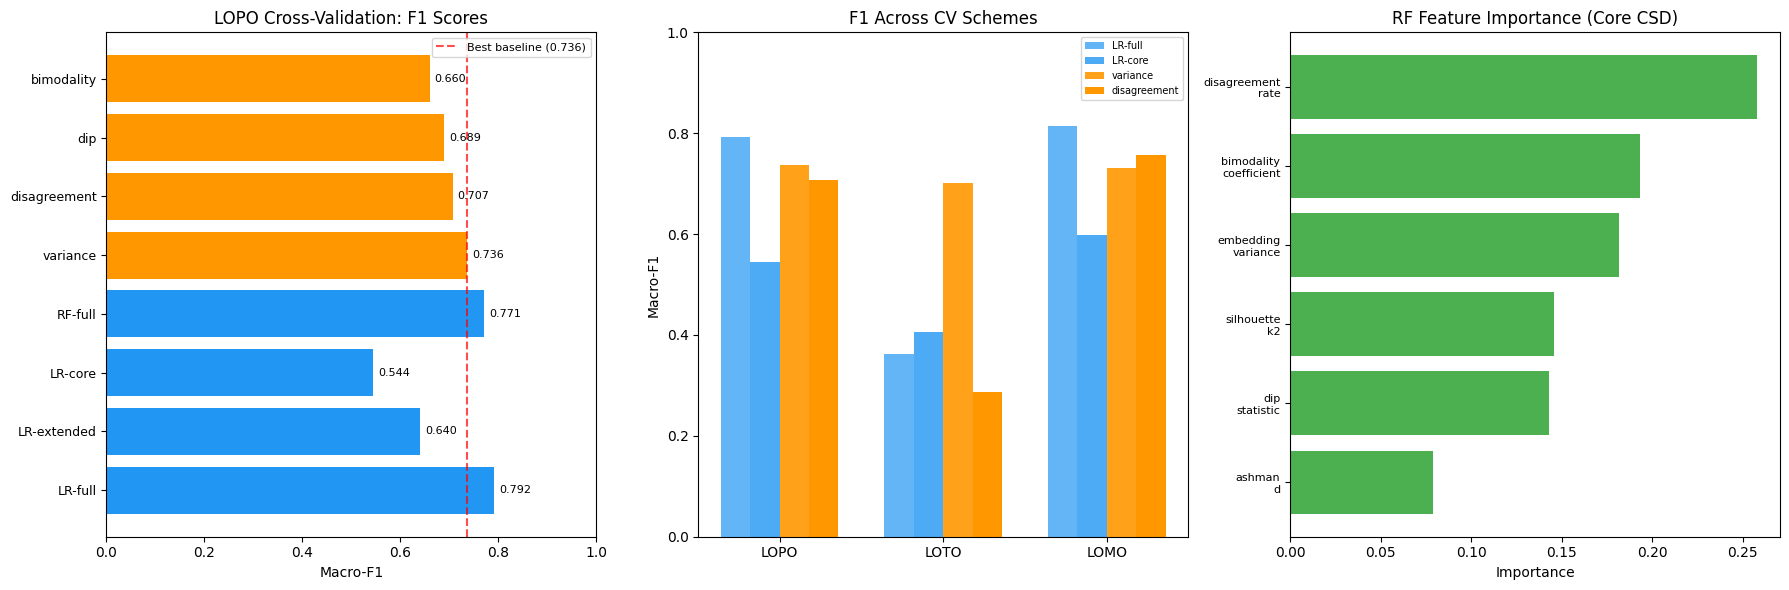

Saved results_summary.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: LOPO F1 comparison (top methods + baselines) ---
ax = axes[0]
# Select key methods for clarity
key_methods = ["csd_logreg_full", "csd_logreg_extended", "csd_logreg_core",
               "csd_rf_full", "variance_only", "disagreement_only", "dip_only", "bimodality_only"]
key_methods = [m for m in key_methods if m in lopo_summary]
f1_vals = [lopo_summary[m]["f1"] for m in key_methods]
colors = ["#2196F3" if m.startswith("csd_") else "#FF9800" for m in key_methods]
short_names = [m.replace("csd_logreg_", "LR-").replace("csd_rf_", "RF-").replace("_only", "") for m in key_methods]

bars = ax.barh(range(len(key_methods)), f1_vals, color=colors)
ax.set_yticks(range(len(key_methods)))
ax.set_yticklabels(short_names, fontsize=9)
ax.set_xlabel("Macro-F1")
ax.set_title("LOPO Cross-Validation: F1 Scores")
ax.set_xlim(0, 1)
ax.axvline(x=best_base_f1, color="red", linestyle="--", alpha=0.7, label=f"Best baseline ({best_base_f1:.3f})")
ax.legend(fontsize=8)
for i, v in enumerate(f1_vals):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)

# --- Plot 2: F1 across CV schemes for best methods ---
ax = axes[1]
schemes = ["LOPO", "LOTO", "LOMO"]
summaries = [lopo_summary, loto_summary, lomo_summary]
top_methods = ["csd_logreg_full", "csd_logreg_core", "variance_only", "disagreement_only"]
top_methods = [m for m in top_methods if m in lopo_summary]

x = np.arange(len(schemes))
width = 0.18
for i, m in enumerate(top_methods):
    f1s = [s.get(m, {}).get("f1", 0) for s in summaries]
    label = m.replace("csd_logreg_", "LR-").replace("_only", "")
    color = "#2196F3" if m.startswith("csd_") else "#FF9800"
    ax.bar(x + i * width, f1s, width, label=label, color=color, alpha=0.7 + 0.1 * i)

ax.set_xticks(x + width * (len(top_methods) - 1) / 2)
ax.set_xticklabels(schemes)
ax.set_ylabel("Macro-F1")
ax.set_title("F1 Across CV Schemes")
ax.legend(fontsize=7, loc="upper right")
ax.set_ylim(0, 1)

# --- Plot 3: Feature importances (core features) ---
ax = axes[2]
if "core" in importance_results:
    imp = importance_results["core"]
    sorted_imp = sorted(imp.items(), key=lambda x: x[1])
    feats = [f[0].replace("_", "\n") for f in sorted_imp]
    vals = [f[1] for f in sorted_imp]
    ax.barh(range(len(feats)), vals, color="#4CAF50")
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats, fontsize=8)
    ax.set_xlabel("Importance")
    ax.set_title("RF Feature Importance (Core CSD)")

plt.tight_layout()
plt.savefig("results_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved results_summary.png")